# Timeseries Tracking Data with GEFF

This notebook shows how to generate temporally coherent mother-machine training data for tracking models, with lineage exported in GEFF format.


## What this workflow does

- Renders sequential frames (no random frame shuffling).
- Keeps optical/noise parameters constant within each series.
- Produces multiple variants (`n_series`) from one simulation.
- Exports lineage for each series as `lineage.geff`.


In [7]:
%load_ext autoreload
%autoreload 2

from SyMBac.simulation import Simulation
from SyMBac.PSF import PSF_generator, Camera
from SyMBac.renderer import Renderer
from SyMBac.misc import get_sample_images
import os


The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


## 1. Run a mother-machine simulation

You can tune low-level physical bendiness with `cell_config_overrides` and
`physics_config_overrides` directly from the notebook.


In [21]:
real_image = get_sample_images()["E. coli 100x"]

# Optional low-level overrides for bendiness/rigidity.
cell_config_overrides = {
    "MAX_BEND_ANGLE": 0.01,            # higher => more bend allowed
    "STIFFNESS": 120_000.0,            # lower => softer bend constraint
    "PIVOT_JOINT_STIFFNESS": 30_000.0,  # lower => more flexible joints
    "NOISE_STRENGTH": 0.08,            # higher => more wiggle
}

physics_config_overrides = {
    "ITERATIONS": 120,  # lower can look floppier, higher more stable/rigid
    "DAMPING": 0.5,
}

my_simulation = Simulation(
    trench_length=14.25,
    trench_width=1.45,
    cell_max_length=4.65,
    cell_width=1.1,
    sim_length=1000,
    pix_mic_conv=0.065,
    gravity=-20,
    phys_iters=15,
    max_length_std=1.0,
    width_std=0.0,
    lysis_p=0.0,
    save_dir="/tmp/symbac_tracking_sim/",
    resize_amount=3,
    substeps=10,
    cell_config_overrides=cell_config_overrides,
    physics_config_overrides=physics_config_overrides,
    brownian_application_mode="velocity",
    brownian_projection_angular_damping=0.30,
    # Brownian jitter core parameters
    brownian_longitudinal_std=0.2,  # microns per frame (start small to avoid over-compression)
    brownian_transverse_std=0.02,    # microns per frame
    brownian_rotation_std=0.02,      # radians per frame
    brownian_persistence=0.10,        # higher => smoother drift
    # Safety guard parameters
    brownian_max_dx_fraction_of_trench_width=0.20,
    brownian_max_dy_fraction_of_segment_radius=0.75,
    brownian_max_dy_px_floor=1.0,
    brownian_max_dtheta=0.03,
    brownian_backoff_attempts=5,
    # If cells compress too much near trench bottom, reduce longitudinal std further
    # or switch to brownian_application_mode="teleport" for gentler jitter.
)

my_simulation.run_simulation(show_window=True)
my_simulation.draw_simulation_OPL(label_masks=True)


Running simulation:   0%|          | 0/1002 [00:00<?, ?it/s]

Rendering cell optical path lengths:   0%|          | 0/1000 [00:00<?, ?it/s]

In [9]:
my_simulation.visualise_in_napari()

OMP: Info #276: omp_set_nested routine deprecated, please use omp_set_max_active_levels instead.


## 2. Build optics + renderer


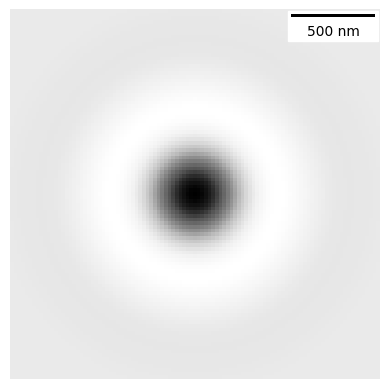

3 (1508, 214)


In [10]:
# A phase contrast kernel
my_kernel = PSF_generator(
    radius = 50, 
    wavelength = 0.75, 
    NA = 1.2, 
    n = 1.3, 
    resize_amount = 3, 
    pix_mic_conv = 0.065, 
    apo_sigma = 20, 
    mode="phase contrast", 
    condenser = "Ph3")
my_kernel.calculate_PSF()
my_kernel.plot_PSF()

my_camera = Camera(baseline=100, sensitivity=2.9, dark_noise=8)

my_renderer = Renderer(
    simulation=my_simulation,
    PSF=my_kernel,
    real_image=real_image,
    camera=my_camera,
    additional_real_images=[real_image],
)


## 3. Set or optimise rendering parameters

If you already have optimised parameters, apply them here. Otherwise run your usual optimisation flow first (manual or `AutoOptimiser`).


In [11]:
# Example: set params from optimise_synth_image widgets / existing config.
my_renderer.select_intensity_napari()
my_renderer.optimise_synth_image(manual_update=False)


/Users/georgeos/GitHub/SyMBac/SyMBac/renderer.py:231: FutureWarning: `napari.view_image` is deprecated and will be removed in napari 0.7.0.
Use `viewer = napari.Viewer(); viewer.add_image(...)` instead.
  viewer = napari.view_image(self.real_resize)


interactive(children=(IntSlider(value=75, description='media_multiplier', max=300, min=-300), FloatSlider(valu…

## 4. Generate one coherent timeseries + GEFF


In [12]:
single_meta = my_renderer.generate_timeseries_training_data(
    save_dir="/tmp/symbac_tracking_data_single_1/",
    burn_in=40,
    sample_amount=0.02,
    n_series=1,
    frames_per_series=200,
    mask_dtype="uint16",
    export_geff=True,
    seed=42,
    n_jobs=1,
    image_format="png",
)

single_meta


KeyboardInterrupt: 

## 5. Generate multiple variants from the same simulation

This gives multiple independent coherent series (`series_000`, `series_001`, ...) with different fixed optical/noise settings per series.


In [ ]:
multi_variant_meta = my_renderer.generate_timeseries_training_data(
    save_dir="/tmp/symbac_tracking_data_multi_variant/",
    burn_in=40,
    sample_amount=0.10,
    n_series=5,
    frames_per_series=150,
    mask_dtype="uint16",
    export_geff=True,
    seed=123,
    n_jobs=1,
    image_format="tiff",
)

multi_variant_meta["n_series"], multi_variant_meta["series"][0]


## 6. Multiple simulations (biological variation) + per-simulation variants

Use an outer loop over simulation parameters, and an inner call to `generate_timeseries_training_data` for optical/noise variants.


In [ ]:
simulation_configs = [
    dict(cell_max_length=6.2, cell_width=1.0),
    dict(cell_max_length=6.8, cell_width=1.1),
]

all_runs = []
for sim_idx, cfg in enumerate(simulation_configs):
    sim = Simulation(
        trench_length=14.25,
        trench_width=1.45,
        cell_max_length=cfg["cell_max_length"],
        cell_width=cfg["cell_width"],
        sim_length=400,
        pix_mic_conv=0.065,
        gravity=0,
        phys_iters=15,
        max_length_std=0.05,
        width_std=0.02,
        lysis_p=0.01,
        save_dir=f"/tmp/symbac_tracking_sim_{sim_idx:03d}/",
        resize_amount=3,
        substeps=100,
    )
    sim.run_simulation(show_window=False)
    sim.draw_simulation_OPL(label_masks=True)

    renderer = Renderer(simulation=sim, PSF=my_kernel, real_image=real_image, camera=my_camera)

    # Apply your preferred renderer params here before export.
    # renderer.params = my_renderer.params

    meta = renderer.generate_timeseries_training_data(
        save_dir=f"/tmp/symbac_tracking_dataset/sim_{sim_idx:03d}/",
        burn_in=40,
        sample_amount=0.08,
        n_series=3,
        frames_per_series=120,
        mask_dtype="uint16",
        export_geff=True,
        seed=1000 + sim_idx,
        n_jobs=1,
        image_format="tiff",
    )
    all_runs.append(meta)

len(all_runs)


## 7. Inspect exported GEFF


In [ ]:
# Requires: pip install "SyMBac[geff]"
# import geff
# graph, metadata = geff.read("/tmp/symbac_tracking_data_single/series_000/lineage.geff")
# print(graph.number_of_nodes(), graph.number_of_edges())
